# K Nearest Neighbors (KNN)

## Concept

KNN is one of the simplest machine learning algorithms.

Instead of learning a mathematical equation like linear regression,
KNN simply looks at **similar data points**.

Idea:

When a new data point arrives, we look at the **K closest points**
from the training dataset and use them to make the prediction.

Example:

If we want to predict whether a fruit is an apple or orange,
we look at the closest fruits in the dataset.

If most of the nearest fruits are apples → prediction = apple.

This is why it is called:

K = number of neighbors  
Nearest = closest points  
Neighbors = similar data points

So the pipeline becomes:

New Data Point
→ Find K closest points
→ Majority vote
→ Predicted class

KNN can be used for:

Classification  
Regression

# Math Behind KNN

The most important part of KNN is calculating **distance** between points.

The most common distance metric is **Euclidean Distance**.

Formula:

distance = √((x₁ - x₂)² + (y₁ - y₂)²)

For multiple dimensions:

distance = √ Σ (xᵢ - yᵢ)²

Where:

x = new data point  
y = training data point  

Steps of KNN:

1. Choose value of K
2. Compute distance from new point to all training points
3. Select K closest points
4. Majority vote for classification
5. Average value for regression

Choosing K:

Small K → Overfitting  
Large K → Underfitting

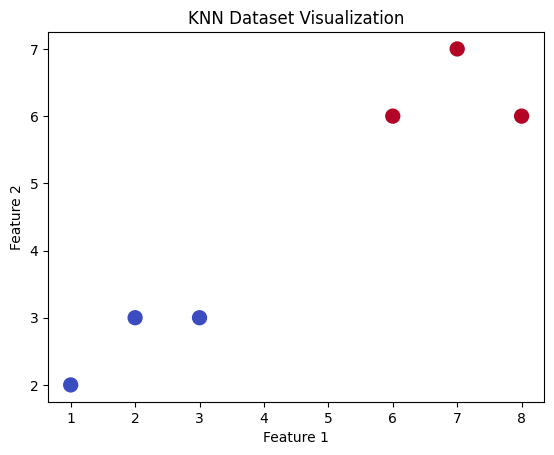

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# simple dataset
X = np.array([[1,2],[2,3],[3,3],[6,6],[7,7],[8,6]])
y = np.array([0,0,0,1,1,1])

plt.scatter(X[:,0],X[:,1],c=y,cmap="coolwarm",s=100)

plt.title("KNN Dataset Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

This shows two clusters of data points.

KNN classifies based on nearest neighbors.

In [4]:
import numpy as np
from collections import Counter

# distance function

def euclidean_distance(a,b):
  return np.sqrt(np.sum((a-b)**2))

# KNN prediction

def knn_predict(X_train,y_train,x,k=3):

  distances_with_labels = [] # Renamed for clarity

  for i in range(len(X_train)):
    dist = euclidean_distance(x,X_train[i])
    distances_with_labels.append((dist, y_train[i])) # Store distance and corresponding label

  distances_with_labels.sort(key=lambda item: item[0]) # Sort by distance

  # Get the labels of the k nearest neighbors
  neighbours_labels = [label for dist, label in distances_with_labels[:k]]

  prediction = Counter(neighbours_labels).most_common(1)[0][0]

  return prediction



X_train = np.array([[1,2],[2,3],[3,3],[6,6],[7,7],[8,6]]) # Fixed [7.7] to [7,7]

y_train = np.array([0,0,0,1,1,1])

new_point = np.array([5,5])

print("Prediction:", knn_predict(X_train,y_train,new_point))

Prediction: 1


This code shows KNN implemented from scratch.



In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

data = load_iris()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.2,
    random_state=42
)

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train,y_train)

accuracy = model.score(X_test,y_test)

print("Accuracy:",accuracy)

Accuracy: 1.0


 this above is a experiment of KNN algorithm  with real dataset of iris dataset

# Summary

KNN is a **non-parametric algorithm**.

This means it does not learn a mathematical model.

Instead it stores the training data and predicts based on similarity.

Key ideas:

Distance metrics determine similarity.

K controls model complexity.

Small K → Overfitting  
Large K → Underfitting

Advantages:

Simple  
No training phase  
Works well for small datasets

Limitations:

Slow for large datasets  
Sensitive to feature scaling